In [1]:
from os import environ
! pip install neptune


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [1]:
def vanilla_attention(d_m, p):
    """Vanilla Transformer:
       N_params = 4*d_m^2
       N_kv = 2*d_m
    """
    return {"N_params": 4 * d_m**2, "N_kv": 2 * p * d_m}


def vanilla_dt(d_m):
    """Vanilla DT:
       Same as Vanilla Transformer:
       N_params = 4*d_m^2
       N_kv = 2*d_m
    """
    return {"N_params": 4 * d_m**2, "N_kv": 2 * d_m}


def gqa_differential_transformer(d_m, p):
    """GQA Differential Transformer:
       N_params = 2*d_m^2 + 2*p*d_m^2
       N_kv = 2*p*d_m
    """
    N_params = 2 * d_m**2 + 2 * p * d_m**2  # equivalent to 2*(1+p)*d_m**2
    N_kv = 2 * p * d_m
    return {"N_params": N_params, "N_kv": N_kv}

def lora_adapter_half_heads(d_m, r):
    """LoRA Adapter, param-matched
       N_params = 3*d_m^2 + 3*d_m*r
       N_kv = 2*d_m
    """
    return {"N_params": 3 * d_m**2 + 3 * d_m * r, "N_kv": 2 * d_m}


def lora_small_kv_cache(d_m, p, r):
    """LoRA Adapter + GQA:
       N_params = 1.5*d_m^2 + 1.5*p*d_m^2 + 2.5*d_m*r + 0.5*p*d_m*r
       N_kv = 2*p*d_m
    """
    N_params = 1.5 * d_m**2 + 1.5 * p * d_m**2 + 2.5 * d_m * r + 0.5 * p * d_m * r
    N_kv = 1.5 * p * d_m + r
    return {"N_params": N_params, "N_kv": N_kv}

def lora_big_kv_cache(d_m, p, r):
    """LoRA Adapter + GQA:
       N_params = 1.5*d_m^2 + 1.5*p*d_m^2 + 2.5*d_m*r + 0.5*p*d_m*r
       N_kv = 2*p*d_m
    """
    N_params = 1.5 * d_m**2 + 1.5 * p * d_m**2 + 2.5 * d_m * r + 0.5 * p * d_m * r
    N_kv = 2 * p * d_m + r
    return {"N_params": N_params, "N_kv": N_kv}


def gda(d_m, n_negative_heads, n_positive_heads): #assuming identity
    """GDA:
       N_params = 3*d_m^2 + (n_negative_heads/n_positive_heads)*d_m^2
       N_kv = 1.5*d_m + (n_negative_heads/n_positive_heads)*0.5*d_m
    """
    N_params = 3 * d_m**2 + (n_negative_heads/n_positive_heads) * d_m**2
    # N_kv = 1.5 * d_m + (n_negative_heads/n_positive_heads) * 0.5 * d_m
    N_kv = 2 * d_m
    return {"N_params": N_params, "N_kv": N_kv}


# def gda_gqa(d_m, n_negative_heads, n_positive_heads, n_kv_heads):
#     """GDA + GQA:
#        N_params = 1.5*d_m^2 + 1.5*p*d_m^2 + (n_negative_heads/n_positive_heads)*d_m^2
#        N_kv = 1.5*p*d_m + 0.5*(n_negative_heads/n_positive_heads)*d_m
#     """
#     assert n_negative_heads <= n_kv_heads
#     assert n_positive_heads % n_kv_heads == 0
#     assert n_positive_heads % n_negative_heads == 0
#     p = n_kv_heads / n_positive_heads
#     N_params = 1.5 * d_m**2 + 1.5 * p * d_m**2 + (n_negative_heads/n_positive_heads) * d_m**2
#     N_kv = 1.5 * p * d_m + 0.5 * (n_negative_heads/n_positive_heads) * d_m
#     return {"N_params": N_params, "N_kv": N_kv}


def swiglu(d_m, dff):
    N_params = 3 * d_m * dff
    N_kv = 0.0
    return {"N_params": N_params, "N_kv": N_kv}


def get_kv_size(row):
    if row['args/attention_mode'] == 'adapter_differential':
        return lora_small_kv_cache(row['args/dmodel'],
        (row['args/n_kv_heads'] or row['args/n_att_heads']) / row['args/n_att_heads'],
        row['args/diff_transformer_lowrank_dim'])['N_kv']
    elif row['args/attention_mode'] == 'adapter_differential_larger_kv_cache':
            return lora_big_kv_cache(row['args/dmodel'],
            (row['args/n_kv_heads'] or row['args/n_att_heads']) / row['args/n_att_heads'],
            row['args/diff_transformer_lowrank_dim'])['N_kv']
    elif row['args/attention_mode'] == 'differential':
        return gqa_differential_transformer(row['args/dmodel'],
            (row['args/n_kv_heads'] or row['args/n_att_heads']) / row['args/n_att_heads'])['N_kv']
    elif row['args/attention_mode'] == 'vanilla':
        return vanilla_attention(row['args/dmodel'],
                                 (row['args/n_kv_heads'] or row['args/n_att_heads']) / row['args/n_att_heads'])['N_kv']
    elif row['args/attention_mode'] == 'gda':
        return gda(
            row['args/dmodel'], row['args/diff_transformer_n_negative_heads'], row['args/n_att_heads'] // 2,
        )['N_kv']
    else:
        return 0.0



In [2]:
import neptune
from os import environ

# Initialize connection to your Neptune project
project = neptune.init_project(
    project="pmtest/llm-random",
    api_token=environ.get('NEPTUNE_API_TOKEN'),
)

# Fetch experiments with the tag "2025_03_08_grid"
runs_table = project.fetch_runs_table(tag=["diff_final_gqa"])

# Convert the runs table to a pandas DataFrame
df = runs_table.to_pandas()

https://app.neptune.ai/pmtest/llm-random/


DataFrame columns: Index(['sys/creation_time', 'sys/description', 'sys/failed', 'sys/group_tags',
       'sys/hostname', 'sys/id', 'sys/modification_time',
       'sys/monitoring_time', 'sys/name', 'sys/owner',
       ...
       'monitoring/f87d6d24/gpu_power_1', 'monitoring/f87d6d24/gpu_power_2',
       'monitoring/f87d6d24/gpu_power_3', 'monitoring/f87d6d24/hostname',
       'monitoring/f87d6d24/memory', 'monitoring/f87d6d24/pid',
       'monitoring/f87d6d24/stderr', 'monitoring/f87d6d24/stdout',
       'monitoring/f87d6d24/tid', 'kv_size'],
      dtype='object', length=2077)


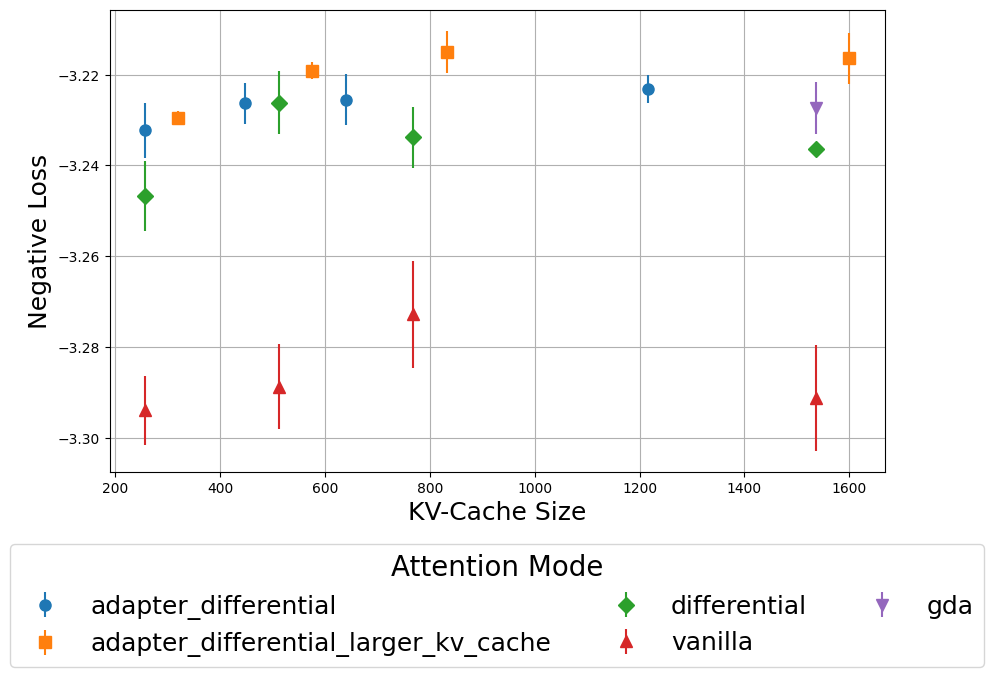

In [68]:
import neptune.new as neptune
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from google.colab import userdata

print("DataFrame columns:", df.columns)

# Remove any rows with missing loss values (if any)
df = df.dropna(subset=["loss_interval/1000"])

# Group experiments by the combination of "args/n_kv_heads" and "args/attention_mode"
def select_best_experiment(group):
    return group.loc[group["loss_interval/1000"].idxmin()]

# best_experiments = df.groupby(["args/n_kv_heads", "args/attention_mode"]).apply(select_best_experiment).reset_index(drop=True)

# Convert "args/n_kv_heads" to numeric if not already
# best_experiments["args/n_kv_heads"] = pd.to_numeric(best_experiments["args/n_kv_heads"], errors="coerce")

# Prepare the scatter plot with different colors for each attention mode
plt.figure(figsize=(10, 6))

# Get unique attention modes and assign a color for each from the 'tab10' colormap.
# attention_modes = best_experiments["args/attention_mode"].unique()

df.loc[df['args/diff_transformer_double_kv_cache'] == True, 'args/attention_mode'] = 'adapter_differential_larger_kv_cache'
attention_modes = df["args/attention_mode"].unique()

df['kv_size'] = df.apply(get_kv_size, axis=1)

colors = plt.cm.tab10(range(len(attention_modes)))
shapes = ['o', 's', 'D', '^', 'v'] #, 'x', 'p', '*']  # Different shapes for each attention mode

# Plot average loss of each group with error bars and label them for the legend.
for attention_mode, color, shape in zip(attention_modes, colors, shapes):
    group = df[df["args/attention_mode"] == attention_mode]
    avg_loss = group.groupby("kv_size")["loss_interval/1000"].mean()
    std_loss = group.groupby("kv_size")["loss_interval/1000"].std()

    plt.errorbar(avg_loss.index, -avg_loss, yerr=std_loss, label=attention_mode, fmt=shape, color=color,
                 markersize=8)
    


# plt.xlabel("kv_size")
plt.xlabel("KV-Cache Size", fontsize=18)
# plt.ylabel("Negative Loss (loss_interval/1000)")
plt.ylabel("Negative Loss", fontsize=18)
# plt.title("Experiments by kv-cache size and attention_mode")
plt.grid(True)
plt.legend(title="Attention Mode", loc="lower center", fontsize=18, title_fontsize=20, ncol=3, bbox_to_anchor=(0.5, -0.45))
plt.savefig("differential_attention_modes.pdf", bbox_inches='tight')
plt.show()

In [12]:
df[["args/attention_mode", "args/n_kv_heads", "loss_interval/1000"]]

,args/attention_mode,args/n_kv_heads,loss_interval/1000
0,adapter_differential,6,3.219688
1,adapter_differential_larger_kv_cache,2,3.229594
2,adapter_differential_larger_kv_cache,2,3.230672
3,adapter_differential,2,3.236000
4,adapter_differential,2,3.235422
5,differential,2,3.238828
6,vanilla,2,3.301094
7,differential,2,3.254203
8,vanilla,2,3.285891
9,adapter_differential_larger_kv_cache,12,3.217625
